In [1]:
# Ensuring fast reload of changes to scripts
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import calc_scc_file, avg_scc, bulk_compare, get_chrs
import pandas as pd
import matplotlib.pyplot as plt

# Validating SCC
To validate the SCC, we will compare SCC scores from differentiating hematopoeitic mouse cells. Intuitively, cells that are apart further in terms of differentiation should show lower SCC scores when compared to cells that are close to each other. For this purpose, we'll use tagHi-C data from Zhang et al (2020). First, for two cells that should be relatively similar, we'll use LT-HSC and ST-HSC data. These are directely related to each other. Then, we'll compare LT-HSCs with MKs, which are quite far apart from one another. The former should give high SCC scores, while the latter should lower lower ones.  

In [2]:
# Comparing LT-HSC and ST-HSC
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data'
lt_hsc = f'{data_dir}/taghic/GSE152918_LT.mcool'
st_hsc = f'{data_dir}/taghic/GSE152918_ST.mcool'

ltst_scc = calc_scc_file(lt_hsc, st_hsc, 10_000, 20, chr_exclude={'M'}) # h = 20 taken from Yang et al (2017) for a 10 kb bin size
ltst_scc_mean = avg_scc(ltst_scc)

# Comparing LT-HSC and MK
mk = f'{data_dir}/taghic/GSE152918_MK.mcool'

ltmk_scc = calc_scc_file(lt_hsc, mk, 10_000, 20, chr_exclude={'M'})
ltmk_scc_mean = avg_scc(ltmk_scc)

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\


In [3]:
# Printing values
print(f'LT-HSC and ST-HSC comparison:\n\n\tSCC array:\n{ltst_scc}\n\n\tAverage SCC:\n{ltst_scc_mean}\n\n')
print(f'LT-HSC and MK comparison:\n\n\tSCC array:\n{ltmk_scc}\n\n\tAverage SCC:\n{ltmk_scc_mean}')

LT-HSC and ST-HSC comparison:

	SCC array:
[0.93398758 0.93466013 0.9398088  0.9308719  0.93740776 0.92573584
 0.95277089 0.94645838 0.93502302 0.93892029 0.94450698 0.93641671
 0.94275518 0.95844455 0.91049689 0.93927542 0.9264868  0.94643119
 0.93428243 0.96010729 0.77298567]

	Average SCC:
0.9308492242478592


LT-HSC and MK comparison:

	SCC array:
[0.79164461 0.78180107 0.78983486 0.79548752 0.77555875 0.75577149
 0.84461738 0.80341463 0.77018796 0.79390019 0.78113357 0.83268188
 0.81818437 0.85855957 0.7280053  0.80749292 0.74237328 0.79456648
 0.79760027 0.88784825 0.62823871]

	Average SCC:
0.78947157497109


The average SCC is more than 0.1 less for the LT-HSC comparison compared to the LT-HSC and ST-HSC comparison. This is promising, as this is a large enough difference to indicate that the cells are further apart from one another, while still indicating a degree of similarity, as all cells are still from the same lineage.    
  
Note that the average SCC may be slightly inaccurate, as it does not take chromosome length into account. For this, the weighted SCC average may be more accurate. Additionally, an image to validate this score would be beneficial, but is challenging due to the contact maps not showing much at smaller bin sizes.

# SCC dependence on chromosome
To further validate the SCC, we will consider the trends of the individual SCC scores per chromosome.

In [4]:
# Getting all files
clp = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_CLP.mcool'
cmp = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_CMP.mcool'
lt = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_LT.mcool'
mk = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_MK.mcool'
st = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/GSE152918_ST.mcool'

files = [clp, cmp, lt, mk, st]

In [6]:
# Get chromosome info
chr_names, chr_lengths = get_chrs(lt, chr_exclude={"M"})
print(chr_names)

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', 'X', 'Y']


In [7]:
# Testing all comparisons, normal avg
sccs, scc_avgs = bulk_compare(files, 10_000, 20, chr_exclude={"M"})

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  assert (cool1.chroms()[:] == cool2.chroms()[:]).all()[0],\
/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/hicrep/hicrep.py:125: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

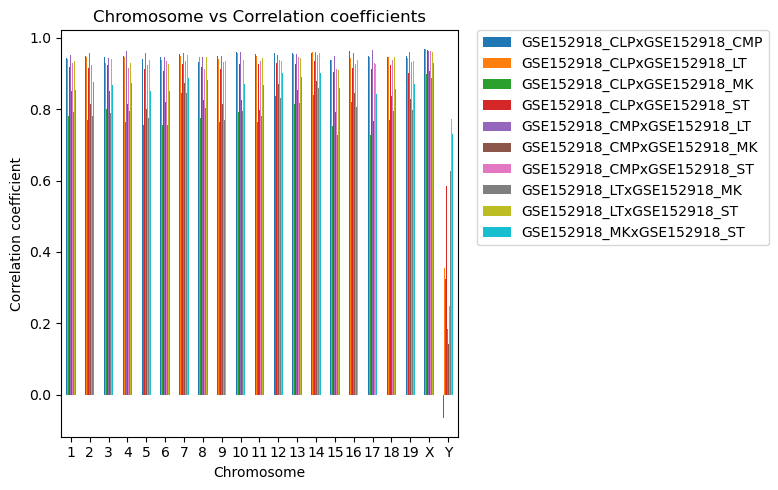

In [9]:
# Constructing a dataframe.
df = pd.DataFrame(sccs)
df.insert(0, "Chromosome", chr_names)

# Visualization
ax = df.plot(
    x="Chromosome",
    kind="bar",
    figsize=(8,5),
    title="Chromosome vs Correlation coefficients"
)

ax.set_ylabel("Correlation coefficient")
ax.set_xticklabels(df["Chromosome"], rotation=0)

# Move legend outside
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.show()